# Исследование ёмкости embedding векторов, когда кол-во фичей = размерности embedding (full basis)

In [360]:
import os, sys

import math
from collections import defaultdict, namedtuple, Counter
import json
import re
import pprint
from enum import Flag, StrEnum, auto # @launchit.collect

from tqdm.notebook import tqdm
import numpy as np
import cupy as cp
import pandas as pd
import einops
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import torch
import torch.optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

project_root_path = ! git rev-parse --show-toplevel
project_root_path = project_root_path[0]

sys.path.append(os.path.join(project_root_path, 'lib'))
from utils import *
from logging_utils import *

# Setup

In [2]:
LOG = Logging.get()
RNG = np.random.default_rng()
ArrayUtils.init()
xp = ArrayUtils.xp

class ExecMode(StrEnum):
    MASTER_NOTEBOOK = auto()
    LAUNCH_NOTEBOOK = auto()
    LAUNCH_MODULE = auto()

CONFIG = namedtuple('Config', 
                    'project_root_path, project_root_uri, subproject_path, data_path, ' + 
                    'self_fname, self_name, ' +
                    'subproject_name,' +
                    'is_cuda, cuda_device, exec_mode, is_interactive')(
    project_root_path=project_root_path,
    project_root_uri=f'com.develorium.{os.path.basename(project_root_path)}',
    subproject_path=os.path.abspath('.'),
    data_path=os.path.join(project_root_path, 'data'),
    self_fname='',
    self_name='',
    subproject_name='',
    is_cuda=torch.cuda.is_available(),
    cuda_device='cuda' if torch.cuda.is_available() else 'cpu',
    exec_mode=ExecMode.MASTER_NOTEBOOK,
    is_interactive=True,
)

if IPython.get_ipython() is None:
    module_fname = __file__
    module_basename = os.path.basename(module_fname)
    module_name, _ = os.path.splitext(module_basename)
    
    CONFIG = CONFIG._replace(self_fname=module_fname, self_name=module_name)
    CONFIG = CONFIG._replace(exec_mode=ExecMode.LAUNCH_MODULE)
else:
    with open(IPython.get_ipython().kernel.config['IPKernelApp']['connection_file'], 'r') as cf:
        notebook_fname = json.load(cf)['jupyter_session']
        notebook_basename = os.path.basename(notebook_fname)
        notebook_name, notebook_ext = os.path.splitext(notebook_basename)
    
        m = re.match(r'(\w+)-Copy\d+$', notebook_name)
    
        if m: notebook_name = m.group(1) # e.g. Cuml is used to be launched from the copy of the notebook

        CONFIG = CONFIG._replace(self_fname=notebook_fname, self_name=notebook_name)
        
        is_launch = re.match(r'\w+-launch\d+$', notebook_name) is not None
        CONFIG = CONFIG._replace(exec_mode=ExecMode.MASTER_NOTEBOOK if not is_launch else ExecMode.LAUNCH_NOTEBOOK)

CONFIG = CONFIG._replace(is_interactive=CONFIG.exec_mode != ExecMode.LAUNCH_MODULE)

CONFIG = CONFIG._replace(subproject_name=os.path.basename(os.path.dirname(CONFIG.self_fname)))
LOG(f'CONFIG=\n{pprint.pformat(CONFIG._asdict(), sort_dicts=False)}\n', when=CONFIG.is_interactive)
LOG(f'CONFIG={CONFIG._asdict()}', when=not CONFIG.is_interactive)

CONFIG=
{'project_root_path': '/home/misha/dev/mine/neurovision',
 'project_root_uri': 'com.develorium.neurovision',
 'subproject_path': '/home/misha/dev/mine/neurovision/14_embedding',
 'data_path': '/home/misha/dev/mine/neurovision/data',
 'self_fname': '/home/misha/dev/mine/neurovision/14_embedding/full_capacity_emb_02.ipynb',
 'self_name': 'full_capacity_emb_02',
 'subproject_name': '14_embedding',
 'is_cuda': False,
 'cuda_device': 'cpu',
 'exec_mode': <ExecMode.MASTER_NOTEBOOK: 'master_notebook'>,
 'is_interactive': True}



Возьмём disentangled representation, когда одна фича - один разряд. В этом случае, сколько разрядов, столько и уникальных фичей можно безупречнно закодировать и декодировать в векторе. 3D -> 3 фичи, 300D -> 300 фичей.

Теперь возьмем distributed representation, где фичи - это направления, которые не на 100% орогональны (т.е. имеется некоторая коррелированность). С одной стороны это плохо, с другой - хорошо, т.к. кол-во фичей, которое можно положить в вектор, увеличивается очень сильно (на порядки). Т.е. закодировать можно много информации. Другой вопрос - а что с раскодировкой, сколько можно прочитать информации без её зашумления?

Зачем HDC?

Если без HDC, то мы остаёмся с disentangled features. Следовательно:
1) Для миллиона фичей, потребовался бы миллион разрядов.
2) 99% разрядов скорее всего были бы забиты 0 - огромный перерасход.
3) т.к. фичи копятся на протяжении жизни, то мы бы платили огромный налог на то, что половина емкости не используется
4) Непонятно, как добавить новую фичу. Увеличивать кол-во разрядов?

Sparsed в том смысле, что не сразу все фичи мы используем, а только небольшую их часть. Например, 80 фич из 1 млн.

# Embedding Size, ES

# Feature Bank Size, FBS

FBS - сколько всего фичей знает система. Банк знаний

# Features Count, FC

FC - сколько фичей (их значений) мы хотим записать в один HDV. Чем больше, тем тяжелее. Если FBS <= EMBEDDING_SIZE, то безошибочно можн сохранить FBS фичей. Если FBS >> EMBEDDING_SIZE, то уже неизбежно будут ошибки, т.к. фичи будут хоть немного, но коррелированы, и сохранение нескольких фичей в один вектор будет приводить к фантомным значениям фичей (которые мы даже и не хотели сохранять).

# get_features_correlation

In [3]:
# features are expected to be in rows and normalized
def get_features_correlation(features, decimals=5):
    dpm = features @ features.T
    r = dpm[np.tril_indices_from(dpm, -1)] # get only lower triangle except diagonal (diagonal contains self-to-self correlation which is not intereseting)

    if decimals is not None:
        return np.round(r, decimals)

    return r

# ES/FBS/FC=768/768/100, как есть

In [146]:
EMBEDDING_SIZE = 768
FEATURES_BANK_SIZE = EMBEDDING_SIZE
FEATURES_COUNT = 100

In [147]:
features = RNG.uniform(-1, +1, size=(FEATURES_BANK_SIZE, EMBEDDING_SIZE))
features = (features.T / np.linalg.norm(features, axis=1)).T # features axes are in rows
assert np.any(~((features @ features.T) == np.eye(len(features)))) # тут не ожидаем Identity матрицы, т.к. фичи всё же слабо, но коррелированы

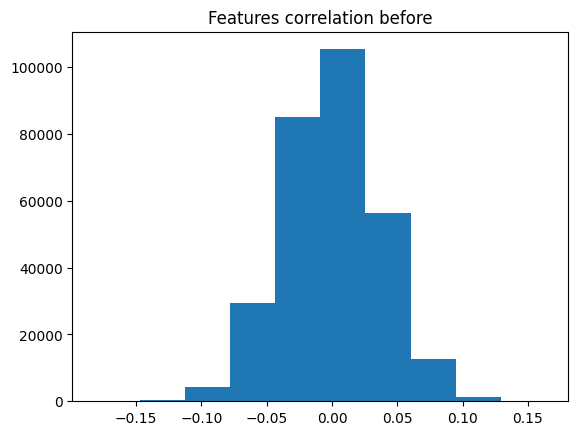

In [148]:
plt.title('Features correlation before')
plt.hist(get_features_correlation(features));

In [149]:
batch_size = 100
batch = np.zeros((batch_size, FEATURES_BANK_SIZE)) 

for i in range(len(batch)):
    feature_inds = RNG.choice(len(features), FEATURES_COUNT, replace=False)
    feature_values = np.zeros(len(features))
    feature_values[feature_inds] = RNG.uniform(0, 1, size=FEATURES_COUNT) # here we get a sparsed vectors
    batch[i] = feature_values 

# encode -> make embedding for each sample in batch: scale each feature by corresponding value, sum all features (disentagled to distributed representation)
# mnemonics: feature (axes) are in columns, samples are in columns. Think model: each basis to vector multiplication
embeddings = (features.T @ batch.T).T
# decode -> extract feature values from embedding
# mnemonics: embedding in rows, features in columns
batch_hat = F.relu(torch.tensor(embeddings @ features.T)).numpy()
mse = ((batch - batch_hat) ** 2).mean()
print(f'MSELoss={mse}')

MSELoss=0.022055844017163574


**ВЫВОДЫ**

Несмотря на гиперразмерность (фичи почти ортогональны), мы видим, что фичи кодируются/декодируются с ошибками. 

# ES/FBS/FC=768/768/768, как есть

In [150]:
EMBEDDING_SIZE = 768
FEATURES_BANK_SIZE = EMBEDDING_SIZE
FEATURES_COUNT = EMBEDDING_SIZE

In [151]:
features = RNG.uniform(-1, +1, size=(FEATURES_BANK_SIZE, EMBEDDING_SIZE))
features = (features.T / np.linalg.norm(features, axis=1)).T # features axes are in rows
assert np.any(~((features @ features.T) == np.eye(len(features)))) # тут не ожидаем Identity матрицы, т.к. фичи всё же слабо, но коррелированы

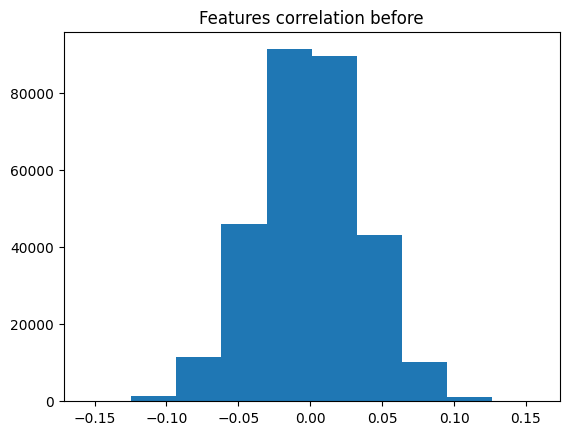

In [152]:
plt.title('Features correlation before')
plt.hist(get_features_correlation(features));

In [153]:
batch = RNG.uniform(0, 1, size=(100, FEATURES_BANK_SIZE)) # each sample contains value for each value
# encode -> make embedding for each sample in batch: scale each feature by corresponding value, sum all features (disentagled to distributed representation)
# mnemonics: feature (axes) are in columns, samples are in columns. Think model: each basis to vector multiplication
embeddings = (features.T @ batch.T).T
# decode -> extract feature values from embedding
# mnemonics: embedding in rows, features in columns
batch_hat = F.relu(torch.tensor(embeddings @ features.T)).numpy()
mse = ((batch - batch_hat) ** 2).mean()
print(f'MSELoss={mse}')

MSELoss=0.23023406382562708


**ВЫВОДЫ**

Несмотря на гиперразмерность (фичи почти ортогональны), мы видим, что фичи кодируются/декодируются с ошибками. По сравнению с предыдущим вариантом ошибка получается заметно выше, что в принципе ожидаемо

# ES/FBS/FC=768/768/768, точное решение

In [154]:
EMBEDDING_SIZE = 768
FEATURES_BANK_SIZE = EMBEDDING_SIZE
FEATURES_COUNT = EMBEDDING_SIZE

QR refresher

In [156]:
any_vector = RNG.uniform(-1, +1, 3)
any_vector /= np.linalg.norm(any_vector)
start_basis = np.eye(len(any_vector))
start_basis[:,0] = any_vector
Q, R = np.linalg.qr(start_basis) 
start_basis, np.round(Q, 2) # bases are in columns

(array([[-0.5784859 ,  0.        ,  0.        ],
        [-0.03935006,  1.        ,  0.        ],
        [ 0.81474268,  0.        ,  1.        ]]),
 array([[-0.58,  0.02,  0.82],
        [-0.04, -1.  ,  0.  ],
        [ 0.81, -0.03,  0.58]]))

In [157]:
np.linalg.norm(Q, axis=0), np.linalg.norm(Q, axis=1), 

(array([1., 1., 1.]), array([1., 1., 1.]))

In [158]:
np.round(start_basis.T @ start_basis, 4), np.round(Q @ Q.T, 4)

(array([[ 1.    , -0.0394,  0.8147],
        [-0.0394,  1.    ,  0.    ],
        [ 0.8147,  0.    ,  1.    ]]),
 array([[ 1., -0., -0.],
        [-0.,  1.,  0.],
        [-0.,  0.,  1.]]))

QR декомпозиция выдаёт базис, который есть в колонках

In [159]:
features = RNG.uniform(-1, +1, size=(FEATURES_BANK_SIZE, EMBEDDING_SIZE))

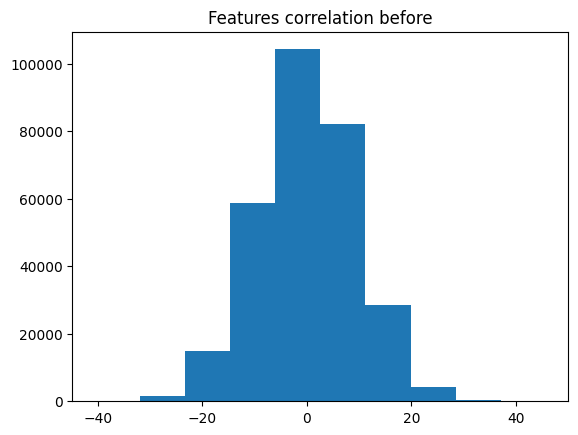

In [160]:
plt.title('Features correlation before')
plt.hist(get_features_correlation(features));

In [161]:
# Получаем из мусора ортогональный базис
features, _ = np.linalg.qr(features)
features = features.T
assert np.all(np.round(features @ features.T, 4) == np.eye(len(features)))

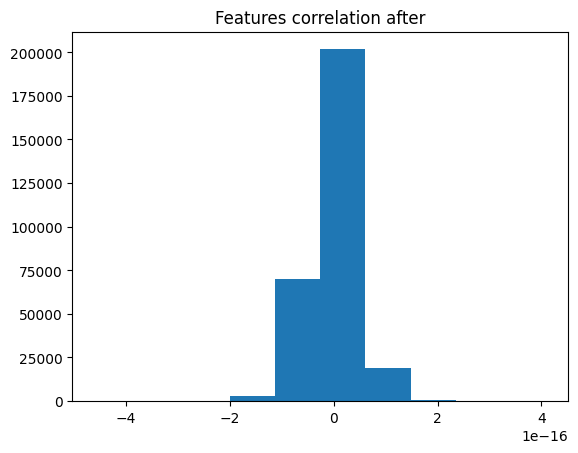

In [162]:
plt.title('Features correlation after')
plt.hist(get_features_correlation(features));

In [163]:
features_count_list = 1 + np.arange(len(features))
diff_metrics = defaultdict(list)

for features_count in tqdm(features_count_list):
    feature_inds = RNG.choice(len(features), features_count, replace=False)
    feature_values = np.zeros(len(features))
    # craft a disentagled representation of features (1 feature = 1 slot)
    feature_values[feature_inds] = RNG.uniform(0, 1, size=(features_count))
    # encode -> make embedding: scale each feature by corresponding value, sum all features (disentagled -> distributed representation)
    embedding = ((features.T * feature_values).T).sum(axis=0) 
    # decode -> extract feature values from embedding
    feature_values_hat = F.relu(torch.tensor(features @ embedding)).numpy()
    # feature_values_hat = (features @ embedding) - bias
    diff = feature_values - feature_values_hat
    abs_diff = np.abs(diff)
    diff_metrics['abs_min'].append(abs_diff.min())
    diff_metrics['abs_max'].append(abs_diff.max())
    diff_metrics['abs_mean'].append(abs_diff.mean())
    diff_metrics['mse_loss'].append((diff ** 2).sum() / len(feature_values))
    diff_metrics['l1_loss'].append(abs_diff.sum() / len(feature_values))

  0%|          | 0/768 [00:00<?, ?it/s]

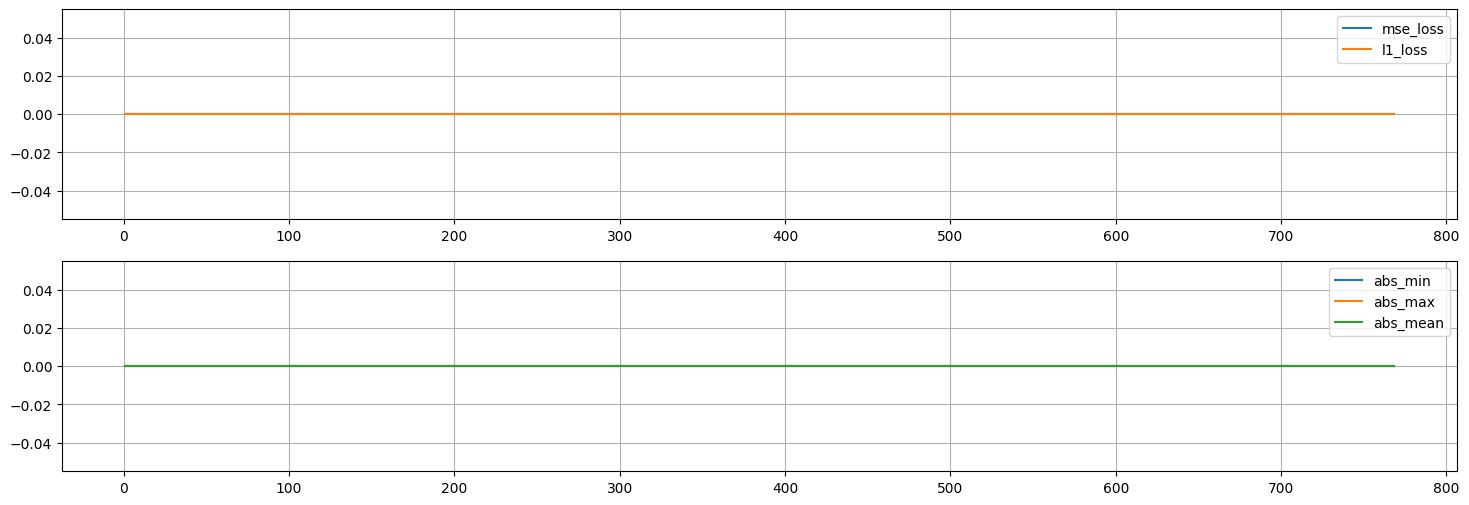

In [164]:
fig, (ax1, ax2) = plt.subplots(2, 1)
fig.set_figwidth(18)
fig.set_figheight(6)

for key in ('mse_loss', 'l1_loss'):
    values = diff_metrics[key]
    ax1.plot(features_count_list, np.round(values, 9), label=key)
    ax1.grid(True)
    ax1.legend();

for key in ('abs_min', 'abs_max', 'abs_mean'):
    values = diff_metrics[key]
    ax2.plot(features_count_list, np.round(values, 9), label=key)
    ax2.grid(True)
    ax2.legend();

**ВЫВОДЫ**

Ожидаемый результат, что когда мы имеем ортогональный базис и размер этого базиса равняется размерности пространства, то в вектор можно идеально закодировать и раскодировать кол-во real-valued фич, равное размерности (например, 768)

# ES/FBS/FC=768/768/768, оптимизация

In [170]:
EMBEDDING_SIZE = 768
FEATURES_BANK_SIZE = EMBEDDING_SIZE
FEATURES_COUNT = EMBEDDING_SIZE

In [171]:
# Стартуем с мусора и пытаемся получить хороший базис через градиентный спуск
features = RNG.uniform(-1, +1, size=(FEATURES_BANK_SIZE, EMBEDDING_SIZE)).astype('float32')
features = (features.T / np.linalg.norm(features, axis=1)).T # features axes are in rows
assert np.any(~((features @ features.T) == np.eye(len(features)))) # тут не ожидаем Identity матрицы, т.к. фичи всё же слабо, но коррелированы
features = torch.tensor(features, requires_grad=True, device=CONFIG.cuda_device)

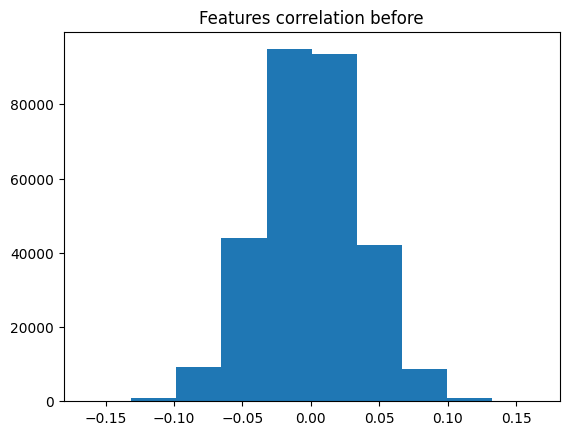

In [172]:
plt.title('Features correlation before')
plt.hist(get_features_correlation(features.detach().cpu().numpy()));

In [173]:
# decorrelate feature axes by gradient descent optimization procedure
optimizer = torch.optim.Adam([features], lr=0.0001)
epochs_count = 6000
batch_size = 100

for epoch in tqdm(range(epochs_count + 1)):
    optimizer.zero_grad()
    batch = RNG.uniform(0, 1, size=(batch_size, FEATURES_BANK_SIZE)).astype('float32') # each sample is a collection of feature values
    batch = torch.tensor(batch, device=CONFIG.cuda_device)
    # encode -> make embedding for each sample in batch: scale each feature by corresponding value, sum all features (disentagled to distributed representation)
    # mnemonics: feature (axes) are in columns, samples are in columns. Think model: each basis to vector multiplication
    embeddings = (features.T @ batch.T).T
    # decode -> extract feature values from embedding
    # mnemonics: embedding in rows, features in columns
    batch_hat = F.relu(embeddings @ features.T) # F.relu is not mandatory but speeds up convergence
    loss = F.mse_loss(batch_hat, batch)

    # construction above resembles autoencoder quite well!!!
    
    if epoch > 0:
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        features[:] = (features.T / torch.linalg.vector_norm(features, dim=1)).T

    if (epoch % 500) == 0:
        print(f'{epoch=}, {loss.item()=}')

  0%|          | 0/6001 [00:00<?, ?it/s]

epoch=0, loss.item()=0.23214250802993774
epoch=500, loss.item()=0.04356537014245987
epoch=1000, loss.item()=0.025324929505586624
epoch=1500, loss.item()=0.014695110730826855
epoch=2000, loss.item()=0.008119571954011917
epoch=2500, loss.item()=0.004071063827723265
epoch=3000, loss.item()=0.0019343503518030047
epoch=3500, loss.item()=0.0006612120778299868
epoch=4000, loss.item()=0.00020901947573293
epoch=4500, loss.item()=8.204017831303645e-06
epoch=5000, loss.item()=1.4673202208825842e-08
epoch=5500, loss.item()=1.3064582402022573e-11
epoch=6000, loss.item()=1.789851768315906e-13


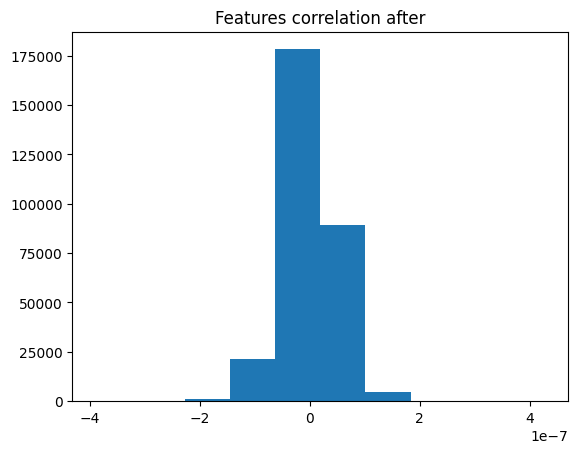

In [177]:
plt.title('Features correlation after')
plt.hist(get_features_correlation(features.detach().cpu().numpy()));

In [178]:
torch.round(features @ features.T, decimals=3)

tensor([[1., -0., 0.,  ..., 0., 0., 0.],
        [-0., 1., 0.,  ..., -0., 0., -0.],
        [0., 0., 1.,  ..., 0., -0., 0.],
        ...,
        [0., -0., 0.,  ..., 1., -0., -0.],
        [0., 0., -0.,  ..., -0., 1., -0.],
        [0., -0., 0.,  ..., -0., -0., 1.]], grad_fn=<RoundBackward1>)

In [179]:
assert torch.all(torch.isclose(torch.linalg.vector_norm(features, dim=1), torch.tensor(1.)))

**ВЫВОДЫ**

1) Если кол-во фичей не превосходит размерность гиперпространства, то можно выйти на ортогональный базис
2) При этом фичи будут кодироваться/декодироваться без ошибки. Т.е. мы итеративно приходим к тому, что получили через QR декомозицию
3) Поиск базиса напоминает автоэнкодер. Или это автоэнкодер напоминает поиск базиса

Зачем HDC?

Если без HDC, то мы остаёмся с disentangled features. Следовательно:
1) Для миллиона фичей, потребовался бы миллион разрядов.
2) 99% разрядов скорее всего были бы забиты 0 - огромный перерасход.
3) т.к. фичи копятся на протяжении жизни, то мы бы платили огромный налог на то, что половина емкости не используется
4) Непонятно, как добавить новую фичу. Увеличивать кол-во разрядов?

Sparsed в том смысле, что не сразу все фичи мы используем, а только небольшую их часть. Например, 80 фич из 1 млн.

# ES/FBS/FC=9/9/9, оптимизация & PCA

Много раз читал, что linear autoencoder реализует PCA. А в PCA как раз фичи ортогональные. Поэтому захотелось проверить это, коль уж такая оказия выдалась. Оказалось, что не всё так просто, хотя и не так сложно. На самом деле, да, linear autoencoder можно заставить делать PCA. Но для этого придётся накинуть пару регулязираций (orthonormal_penalty), а также сделать ирерахический loss. См. метод 3 и метод 7.

Ну и одновременно эпичный и типичный был фейл с проверкой на eigvecs. Очень долго я сравнивал фичи не с тем, что надо. Аргххх!!!

Тут диалог: <a href="./dialogs/linear_autoencoder_and_pca.ipynb">linear_autoencoder_and_pca.ipynb</a>

In [413]:
EMBEDDING_SIZE = 9
FEATURES_BANK_SIZE = 9

In [460]:
# Стартуем с мусора и пытаемся получить хороший базис через градиентный спуск
features = RNG.uniform(-1, +1, size=(FEATURES_BANK_SIZE, EMBEDDING_SIZE)).astype('float32')
features = (features.T / np.linalg.norm(features, axis=1)).T # features axes are in rows
assert np.any(~((features @ features.T) == np.eye(len(features)))) # тут не ожидаем Identity матрицы, т.к. фичи всё же слабо, но коррелированы
original_features = features.copy()
features = torch.tensor(features, requires_grad=True, device=CONFIG.cuda_device)

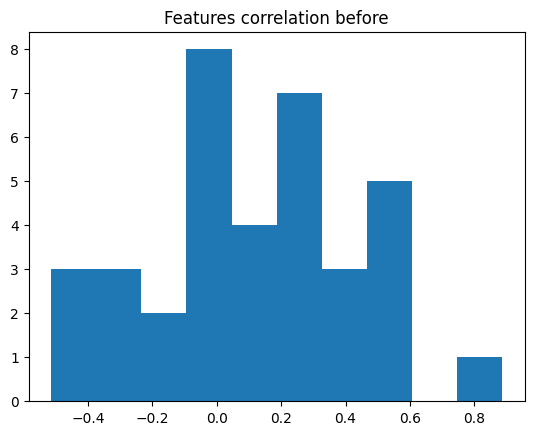

In [461]:
plt.title('Features correlation before')
plt.hist(get_features_correlation(features.detach().cpu().numpy()));

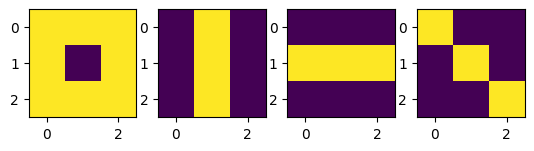

In [462]:
box_sample = ArrayUtils.v2sm(np.zeros(FEATURES_BANK_SIZE, dtype='float32'))
box_sample[0] = 1
box_sample[-1] = 1
box_sample[:,0] = 1
box_sample[:,-1] = 1

vert_line_sample = ArrayUtils.v2sm(np.zeros(FEATURES_BANK_SIZE, dtype='float32'))
vert_line_sample[:,1] = 1

horz_line_sample = ArrayUtils.v2sm(np.zeros(FEATURES_BANK_SIZE, dtype='float32'))
horz_line_sample[1] = 1

diag_line_sample = np.eye(int(np.sqrt(FEATURES_BANK_SIZE)))

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4)
ax1.imshow(box_sample)
ax2.imshow(vert_line_sample)
ax3.imshow(horz_line_sample);
ax4.imshow(diag_line_sample);

In [463]:
dataset = np.zeros((1000, *box_sample.shape), dtype='float32')
samples = [box_sample, vert_line_sample, horz_line_sample, diag_line_sample]

for i, sample_ind in enumerate(RNG.choice(len(samples), len(dataset), p=[0.5, 0.2, 0.2, 0.1])):
    dataset[i] = samples[sample_ind]

dataset = einops.rearrange(dataset, 'b h w -> b (h w)')

# Если подмешать достаточное число рандомных сэмплов, то для получения ортонормальных фичей можно будет обойтись без orthonormal_penalty.
# Если не подмешивать, то придётся использовать orthonormal_penalty
if False:
    mixin_random_samples = RNG.uniform(0, 1, size=(100, FEATURES_BANK_SIZE)).astype('float32') # each sample is a collection of feature values
    dataset = np.r_[dataset, mixin_random_samples]

scaler = StandardScaler()
dataset = scaler.fit_transform(dataset)

In [464]:
# decorrelate feature axes by gradient descent optimization procedure
optimizer = torch.optim.Adam([features], lr=0.0001)
epochs_count = 30_000
batch_size = 100

for epoch in tqdm(range(epochs_count + 1)):
    optimizer.zero_grad()
    dataset_inds = RNG.choice(len(dataset), size=batch_size, replace=False)
    batch = dataset[dataset_inds]
    batch = torch.tensor(batch, device=CONFIG.cuda_device)

    method = 6
    variance_order_penalty = torch.tensor(0.0)
    
    if method == 1:
        # Взгляд ф-ля "Синтез".
        # Считаем, что каждый элемент в сэмлпе батча - это коэффициент линейной комбинации для фичи (масштабируемый множитель фичи).
        # Соответственно эмбеддинг собирается как линейная комбинация фичей (линейная комбинация строк из features). А дальше мы смотрим
        # на проекции эмбеддинг вектора на каждую из фичей - должны восстановить исходный батч.
        # Здесь будет тривиальное решение - Identiy матрица. 
        # При наличии рандом сэмплов в датасете подойдёт любой набор взаимно ортогональных фичей. Без рандом сэмплов сгодится даже неортогональный набор фичей.
        # PCA тут не получится, т.к. даже при ортогональном базисе мы никак не заставляем, чтобы первая фича описывала макс. вариации, сумма первых двух ещё большей вариации и т.д.
        # Да даже ещё глубже проблема. Проблема в интерпретации элементов сэмпла батча как коэффициентов для фич. Это было бы норм, если бы элементы батча уже были бы эмбеддингов
        # а тут элементы сэмпла батча - это пиксели. Каждый PC должен "впитывать" данные из всего вектора сэмпла, а не только из какого-то одного компонента
        
        # encode -> make embedding for each sample in batch: scale each feature by corresponding value, sum all features (disentagled to distributed representation)
        # mnemonics 4
        embeddings = batch @ features
        # decode -> extract feature values from embedding
        # mnemonics 5
        batch_hat = embeddings @ features.T
        loss = F.mse_loss(batch_hat, batch)
    elif method == 2:
        # Doomed approach. Тут была попытка остаться в режиме "Синтез" (а-ля линейная комбинация фичей по пикселам).
        # Но это не получится, т.к. каждая PC компонента должна "впитывать" данные из сэмпла-вектора целиком, а не из одного выделенного элемента
        embeddings = batch @ features
        batch_hat = embeddings @ features.T
        basic_loss = F.mse_loss(batch_hat, batch)
        
        total_loss = 0
    
        for i in range(1, FEATURES_BANK_SIZE + 1):
            # Take only the first 'i' coefficients from the batch and corresponding first 'i' feature rows
            partial_batch = batch[:,:i] # left i columns
            partial_features = features[:i,:] # top i rows
            partial_embeddings = partial_batch @ partial_features
            batch_hat = partial_embeddings @ features.T
            total_loss += F.mse_loss(batch_hat, batch)

            # batch_hat = partial_embeddings @ partial_features.T
            # total_loss += F.mse_loss(batch_hat, partial_batch)

            # total_loss += F.mse_loss(partial_embeddings, batch)
    elif method == 3:
        # Режим "Анализ". Тут мы как раз смотрим на то, как каждый из фича векторов "впитывает" данные из всего сэмпла вектора.
        # И тут мы заставляем variance ordering:
        # - сначала первый компонент только, потеря должна быть минимальна
        # - сумма первого и второго компонента, потеря должны быть минимальна
        # - ... вплоть до суммы всех компонентов
        # Тут уже получается PCA
        projections = batch @ features.T 
        batch_hat = projections @ features
        basic_loss = F.mse_loss(batch_hat, batch)
        total_loss = 0

        for i in range(1, FEATURES_BANK_SIZE + 1):
            # 1. Grab the current basis (top i rows)
            sub_basis = features[:i, :]
            
            # 2. CALCULATE the correct coefficients for this basis
            # This replaces your 'partial_batch = batch[:, :i]'
            optimal_coeffs = batch @ sub_basis.T 
            
            # 3. SYNTHESIS: Build it back up
            batch_hat = optimal_coeffs @ sub_basis

            # 4. COMPARE to the original data
            total_loss += F.mse_loss(batch_hat, batch)
    elif method == 4:
        # Режим "Анализ". Тут я неправильно думал, что каждый компонет (фича вектор) должен 
        # описывать все меньше и меньше вариации. На самом деле должна быть кумулятивная история:
        # - первый компонент описывает максимально возможную вариацию для одного вектора
        # - сумма первого и второго компонента описываются максимально возможную вариацию для двух векторов
        # - ... сумма всех компонентов описываются всю возомжную вариацию
        projections = batch @ features.T 
        batch_hat = projections @ features
        basic_loss = F.mse_loss(batch_hat, batch)
        total_loss = 0
        
        subbasis_losses = torch.zeros(len(features))

        for i in range(0, FEATURES_BANK_SIZE):
            subbasis = einops.rearrange(features[i], 'v -> 1 v')
            projections = batch @ subbasis.T 
            batch_hat = projections @ subbasis
            subbasis_losses[i] = F.mse_loss(batch_hat, batch)

        diffs = torch.diff(subbasis_losses)
        variance_order_penalty = (torch.relu(diffs) ** 2).sum()
        total_loss = basic_loss + variance_order_penalty
    elif method == 5:
        # Режим "Анализ". Тут чуть лучше чем метод 4, но недостаточно. Слишком слабый штраф, т.к.
        # оптимизация удовлетворяется когда хотя бы чуть меньше PC1 <= PC1+PC2 <= PC1+PC2+PC3...
        projections = batch @ features.T 
        batch_hat = projections @ features
        basic_loss = F.mse_loss(batch_hat, batch)
        
        subbasis_losses = torch.zeros(len(features))

        for i in range(1, FEATURES_BANK_SIZE + 1):
            subbasis = features[:i]
            projections = batch @ subbasis.T 
            batch_hat = projections @ subbasis
            subbasis_loss = F.mse_loss(batch_hat, batch)
            subbasis_losses[i-1] = subbasis_loss

        diffs = torch.diff(subbasis_losses)
        variance_order_penalty = (torch.relu(diffs) ** 2).sum()
        
        total_loss = basic_loss + variance_order_penalty
    elif method == 6:
        # Режим "Анализ". Эквивалент методу №3
        projections = batch @ features.T 
        batch_hat = projections @ features
        basic_loss = F.mse_loss(batch_hat, batch)
        total_loss = 0

        for i in range(1, FEATURES_BANK_SIZE + 1):
            subbasis = features[:i]
            projections = batch @ subbasis.T 
            batch_hat = projections @ subbasis
            subbasis_loss = F.mse_loss(batch_hat, batch)
            total_loss += subbasis_loss
            
    elif method == 7:
        # Режим "Анализ". Эквивалент методу №3 с дополнительными весами, чтобы ещё больше подчернуть важность PC1 <= PC1+PC2 <= PC1+PC2+PC3...
        projections = batch @ features.T 
        batch_hat = projections @ features
        basic_loss = F.mse_loss(batch_hat, batch)
        total_loss = 0

        for i in range(1, FEATURES_BANK_SIZE + 1):
            subbasis = features[:i]
            projections = batch @ subbasis.T 
            batch_hat = projections @ subbasis
            subbasis_loss = 2 ** (FEATURES_BANK_SIZE - i) * F.mse_loss(batch_hat, batch)
            total_loss += subbasis_loss
        
    orthonormal_penalty = F.mse_loss(features @ features.T, torch.eye(FEATURES_BANK_SIZE))
    total_loss += orthonormal_penalty

    if epoch > 0:
        total_loss.backward()
        optimizer.step()

    if (epoch % 1000) == 0:
        print(f'{epoch=}, ' + 
              f'basic_loss={basic_loss.item():.5g}, ' + 
              f'variance_order_penalty={variance_order_penalty.item():.5g}, ' + 
              f'orthonormal_penalty={orthonormal_penalty.item():.5g}, ' + 
              f'total_loss={total_loss.item():<50.5g}', end='\r')

  0%|          | 0/30001 [00:00<?, ?it/s]

epoch=30000, basic_loss=4.5718e-09, variance_order_penalty=0, orthonormal_penalty=1.7926e-10, total_loss=0.35235                                           

In [471]:
pca = PCA()
pca.fit(dataset)

for i in range(len(pca.components_)):
    pc_comp = pca.components_[i]
    dps = pc_comp @ features.T.detach().cpu().numpy()
    print(f'pc_comp #{i}, max dot prod={np.max(np.abs(dps)):.2f}')

pc_comp #0, max dot prod=1.00
pc_comp #1, max dot prod=1.00
pc_comp #2, max dot prod=1.00
pc_comp #3, max dot prod=0.62
pc_comp #4, max dot prod=0.65
pc_comp #5, max dot prod=0.72
pc_comp #6, max dot prod=0.61
pc_comp #7, max dot prod=0.74
pc_comp #8, max dot prod=0.93


In [472]:
U, S, V = np.linalg.svd(dataset)
eigvecs = V

for i in range(len(eigvecs)):
    eigvec = eigvecs[i]
    dps = eigvec @ features.T.detach().cpu().numpy()
    print(f'eigvec #{i}, max dot prod={np.max(np.abs(dps)):.2f}')

eigvec #0, max dot prod=1.00
eigvec #1, max dot prod=1.00
eigvec #2, max dot prod=1.00
eigvec #3, max dot prod=0.61
eigvec #4, max dot prod=0.73
eigvec #5, max dot prod=0.55
eigvec #6, max dot prod=0.66
eigvec #7, max dot prod=0.74
eigvec #8, max dot prod=0.55


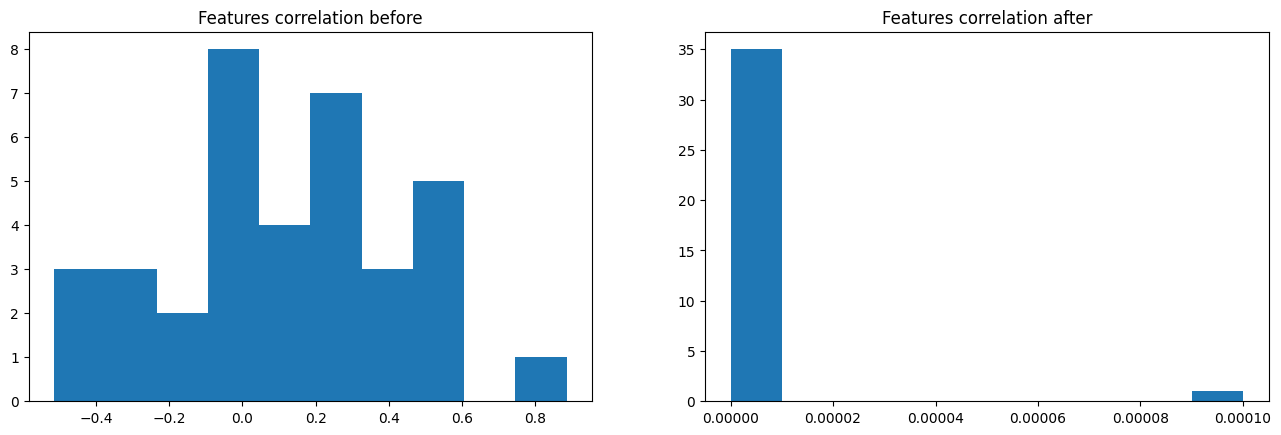

In [473]:
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figwidth(16)
ax1.set_title('Features correlation before')
ax1.hist(get_features_correlation(original_features))
ax2.set_title('Features correlation after')
ax2.hist(get_features_correlation(features.detach().cpu().numpy(), 4));

# Справочно

## Размер встраивания для GPT

| Model | Embedding Size (Dimensions) |
|---|---|
| GPT-1 | 768 |
| GPT-2 | 1,600 (for the 1.5B model) |
| GPT-3 | 12,288 |
| GPT-4 | ~16,000 (Estimated) |
| GPT-5 | Not officially released |


## Кол-во слоёв GPT

| Model [2, 3, 4, 5, 6, 7, 8, 9] | Layers (Transformer Blocks) | Parameters (Largest Version) |
|---|---|---|
| GPT-1 | 12 | 117 Million |
| GPT-2 | 48 | 1.5 Billion |
| GPT-3 | 96 | 175 Billion |
| GPT-4 | ~120–128* | 1.7–1.8 Trillion (Estimated) |
| GPT-5 | 48* | Unknown (Projected MoE architecture) |
